In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import string

In [2]:
benchmark_data = pd.read_csv("results/combined_results.csv")
benchmark_data.head()

,service,scenario,comparison,filter,elapsed_time_seconds
0,NWM API V2,retrospectives,1,HUC-0305010505,5.832636
1,NWM API V2,retrospectives,1,HUC-030501050505,1.599326
2,NWM API V2,retrospectives,1,REACH-12034579,1.283794
3,NWM API V2,retrospectives,2,HUC-0305010505,9.580900
4,NWM API V2,retrospectives,2,HUC-030501050505,1.941154


/var/folders/8r/62hqn3w12tsbjnhf6wbk7g9w0000gs/T/ipykernel_3659/156451522.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


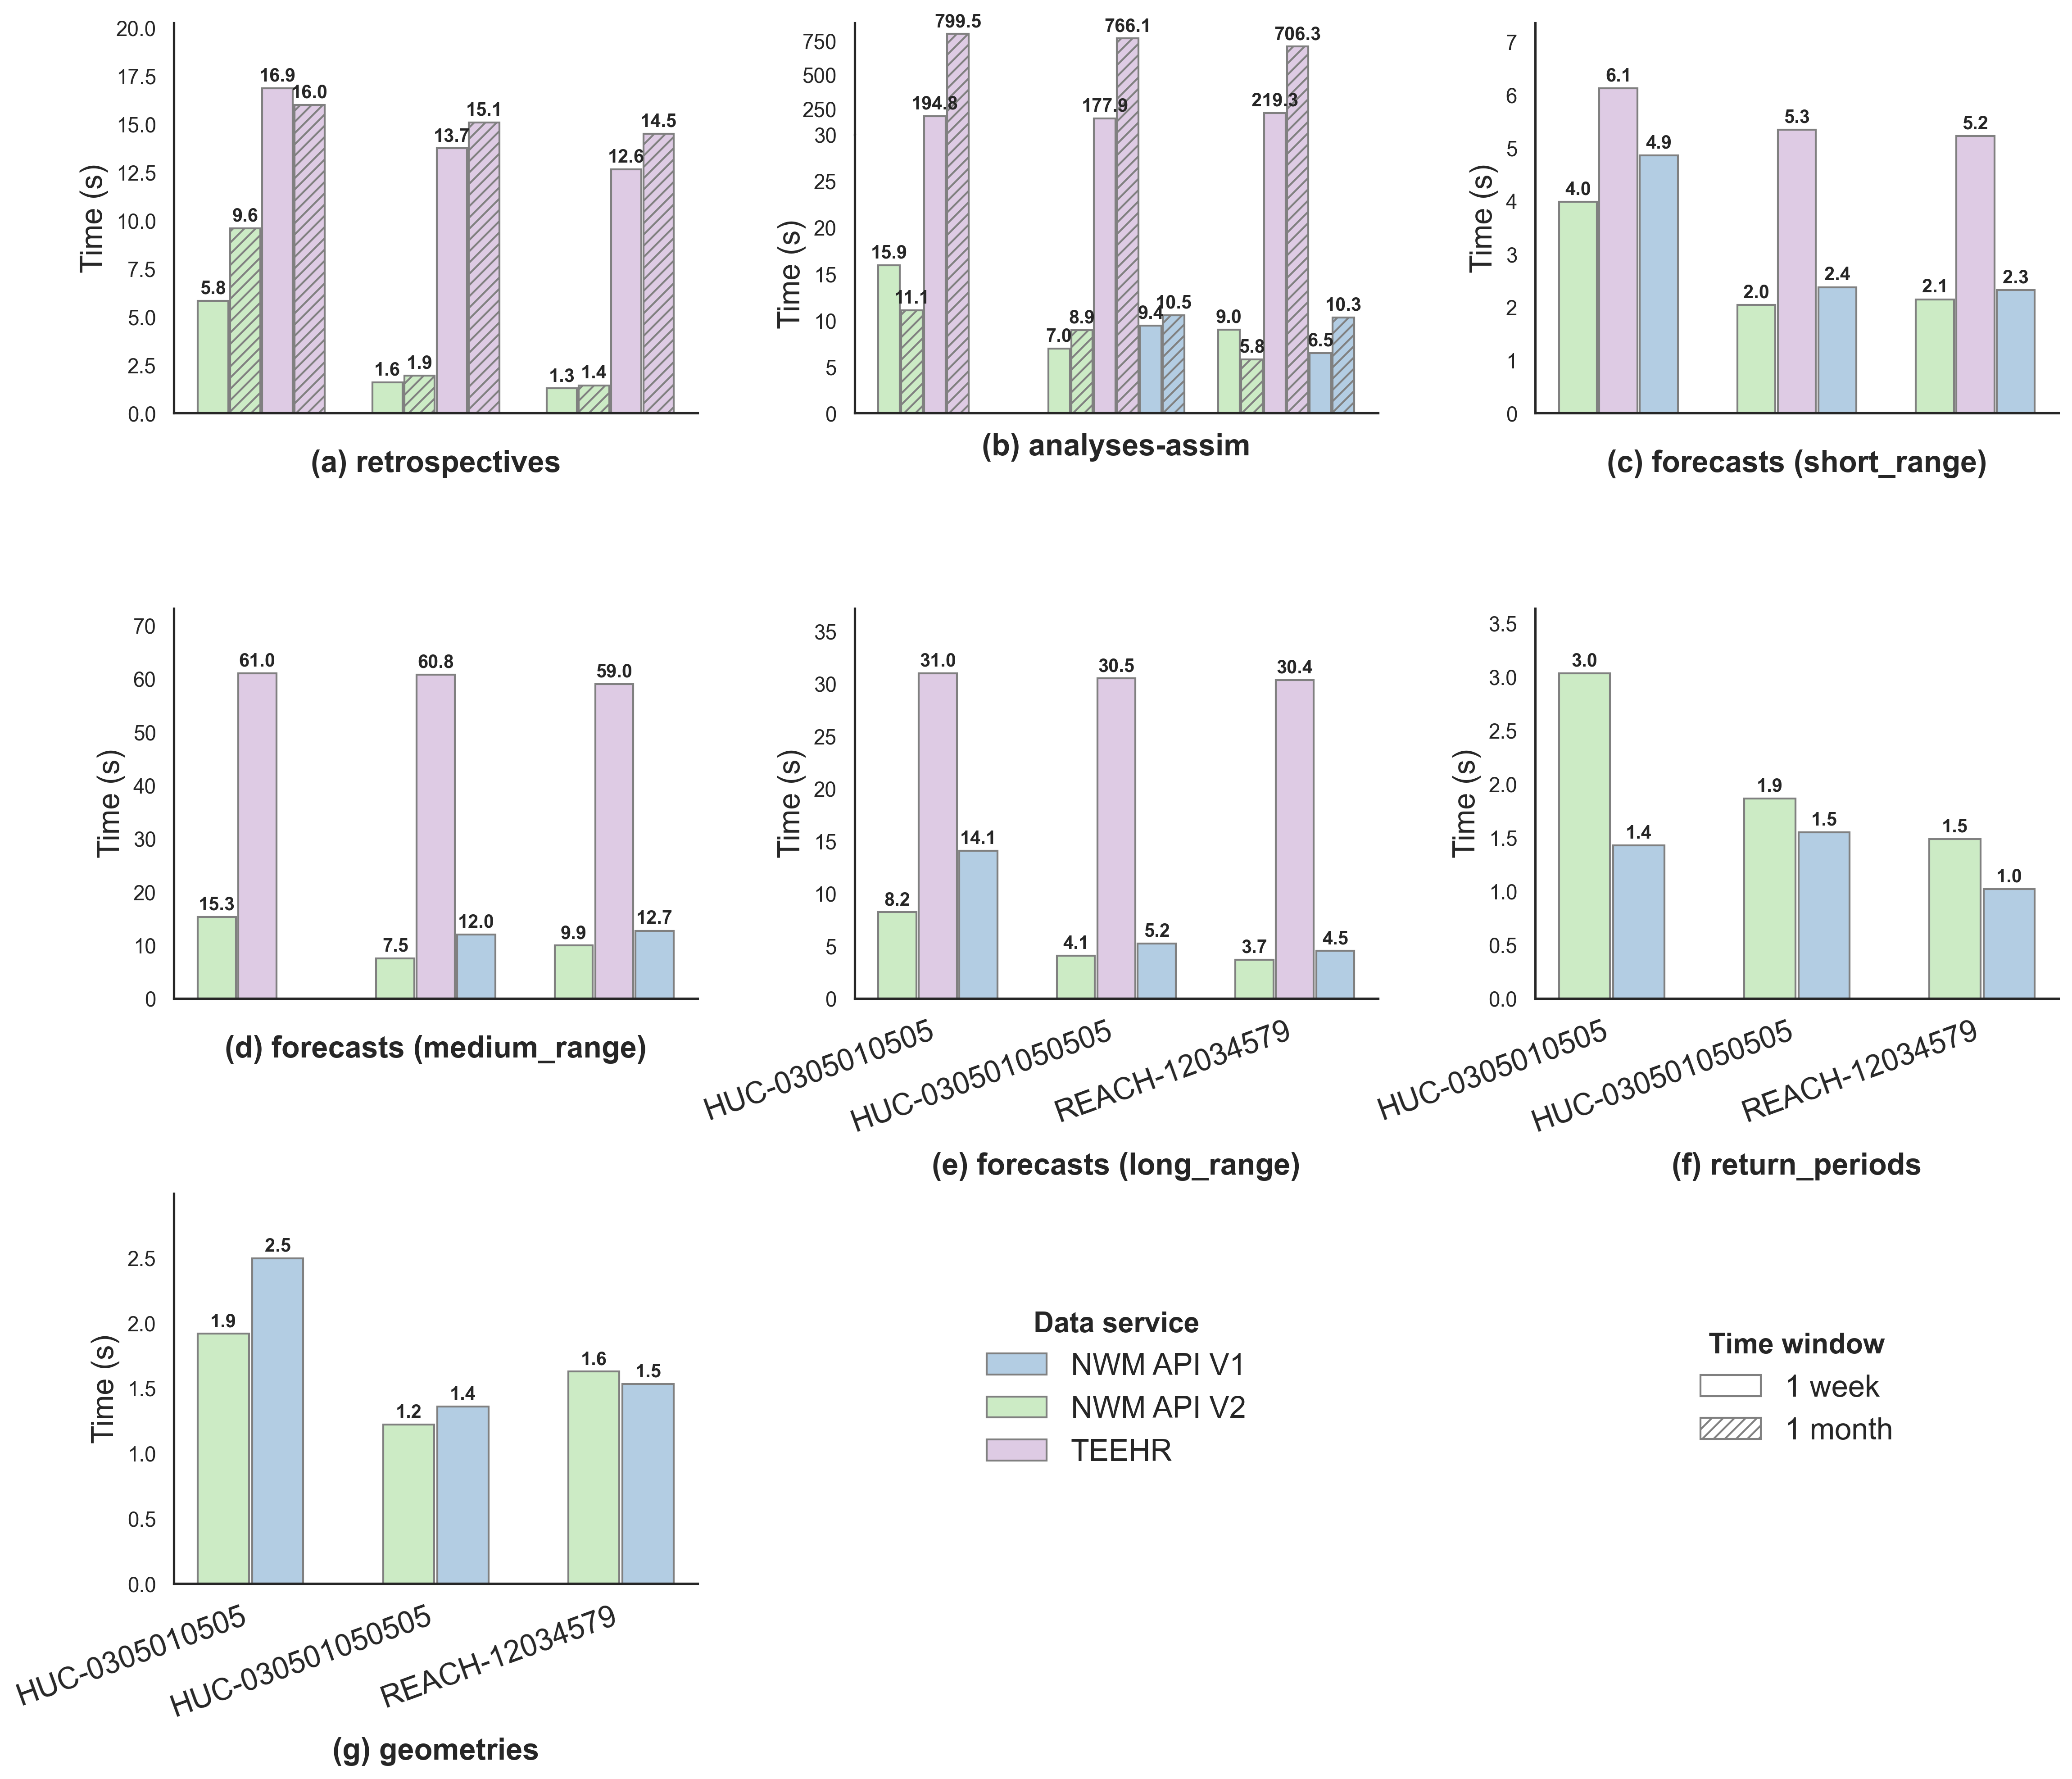

In [7]:
# 1. Setup Theme
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 16, 'figure.dpi': 300, 'font.family': 'sans-serif'})

scenarios = benchmark_data['scenario'].unique()
n_rows, n_cols = 3, 3 

fig = plt.figure(figsize=(18, 15)) 
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.5, wspace=0.3) 

# Shared configuration
bar_width, inter_bar_gap, cluster_gap = 0.8, 0.05, 1.2
hatches = ['', '////']
unique_services = sorted(benchmark_data['service'].unique())
colors_from_palette = sns.color_palette("Pastel1", len(unique_services)+1)
color_map = {unique_services[0]: colors_from_palette[1], 
             unique_services[1]: colors_from_palette[2],
             unique_services[2]: colors_from_palette[3]}
global_service_handles = {}

# Alphabet list for labels
alphabet_labels = [f"({char})" for char in string.ascii_lowercase]

for idx, scenario_name in enumerate(scenarios):
    r, c = divmod(idx, n_cols)
    is_broken = (scenario_name == 'analyses-assim')
    is_bottom_of_col = (idx + n_cols >= len(scenarios))

    if is_broken:
        inner_gs = gs[r, c].subgridspec(2, 1, height_ratios=[1, 2.5], hspace=0.0)
        ax_top = fig.add_subplot(inner_gs[0])
        ax_bot = fig.add_subplot(inner_gs[1], sharex=ax_top)
    else:
        inner_gs = gs[r, c].subgridspec(1, 1)
        ax_bot = fig.add_subplot(inner_gs[0])
        ax_top = ax_bot 

    data_subset = benchmark_data[benchmark_data['scenario'] == scenario_name]
    current_x = 0
    filter_ticks, filter_labels = [], []

    for filter_id in data_subset['filter'].unique():
        cluster_subset = data_subset[data_subset['filter'] == filter_id]
        start_x = current_x
        for i, (_, row) in enumerate(cluster_subset.iterrows()):
            service = row['service']
            val = row['elapsed_time_seconds']
            if scenario_name in ['retrospectives', 'analyses-assim']:
                h = hatches[i % len(hatches)]
            else:
                h = ''

            if is_broken:
                ax_top.bar(current_x, val, width=bar_width, color=color_map[service], edgecolor='grey', hatch=h)
            
            bar_container = ax_bot.bar(current_x, val, width=bar_width, color=color_map[service], edgecolor='grey', hatch=h)
            
            target_ax = ax_top if (is_broken and val > 30) else ax_bot
            target_ax.bar_label(bar_container, fmt='%.1f', padding=2, fontweight='bold', fontsize=10)

            if service not in global_service_handles:
                global_service_handles[service] = bar_container[0]
            current_x += (bar_width + inter_bar_gap)
        
        filter_ticks.append((start_x + current_x - (bar_width + inter_bar_gap)) / 2)
        filter_labels.append(filter_id)
        current_x += cluster_gap

    y_pos = -0.45 if is_bottom_of_col else -0.15
    label_text = f"{alphabet_labels[idx]} {scenario_name.lower()}"
    ax_bot.text(0.5, y_pos, label_text, transform=ax_bot.transAxes, 
                ha='center', fontweight='bold', fontsize=16)

    if is_broken:
        ax_top.set_ylim(60, data_subset['elapsed_time_seconds'].max() * 1.1)
        ax_bot.set_ylim(0, 30)
        ax_top.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)
        ax_top.tick_params(labelbottom=False, bottom=False)
    else:
        ax_bot.set_ylim(0, data_subset['elapsed_time_seconds'].max() * 1.2)

    ax_bot.set_xticks(filter_ticks)
    if is_bottom_of_col:
        ax_bot.set_xticklabels(filter_labels, rotation=20, ha='right', fontsize=16)
    else:
        ax_bot.tick_params(labelbottom=False)

    ax_bot.set_ylabel('Time (s)', fontsize=16)
    sns.despine(ax=ax_bot)
    if is_broken: sns.despine(ax=ax_top, bottom=True)

# 3. Legend Placement (Vacant grids)
service_keys = sorted(global_service_handles.keys())
h_service = [global_service_handles[k] for k in service_keys]
h_method = [
    mpatches.Patch(facecolor='white', edgecolor='grey', hatch='', label='1 week'),
    mpatches.Patch(facecolor='white', edgecolor='grey', hatch='////', label='1 month')
]

ax_leg1 = fig.add_subplot(gs[2, 1])
ax_leg1.axis('off')
ax_leg1.legend(handles=h_service, labels=service_keys, title="Data service", 
               loc='center', frameon=False, fontsize=16, title_fontproperties={'weight':'bold', 'size':15})

ax_leg2 = fig.add_subplot(gs[2, 2])
ax_leg2.axis('off')
ax_leg2.legend(handles=h_method, labels=['1 week', '1 month'], title="Time window", 
               loc='center', frameon=False, fontsize=16, title_fontproperties={'weight':'bold', 'size':15, 'family':'sans-serif'})
plt.tight_layout()
plt.savefig("figures/comparison_all_services.png", bbox_inches='tight')
plt.savefig("figures/comparison_all_services.pdf", bbox_inches='tight')
plt.show()